# **Damped Burgers** — $-\tfrac{\lambda}{2}\partial_x(\phi^2)$ (composite $\partial_x$ vertex, d = 1)

$$\partial_t\phi = -\mu\phi + D\,\partial_x^2\phi - \tfrac{\lambda}{2}\partial_x(\phi^2) + \eta
  \;=\; -\mu\phi + D\,\partial_x^2\phi - \lambda\,\phi\,\partial_x\phi + \eta,\qquad
  \langle\eta\eta\rangle = 2T\,\delta\,\delta.$$

The linear damping $-\mu\phi$ gives a massive, IR-safe propagator and fixes the homogeneous saddle
$\phi^*=0$.  The $\partial_x$ acts on the $\phi^2$ **composite** — a *first*-derivative vertex, so its
form factor is **imaginary** ($\partial_x\to ik$), unlike Model B's real $\nabla^2\to-k^2$.
Expanding about the saddle also makes a bilinear $\propto\phi^*\,\partial_x(\delta\phi)$, a propagator
**drift** that vanishes at $\phi^*=0$ (the drift-generalized heat kernel handles it).

In [1]:
import os, sys, time
# --- depth-robust repo root: walk up until we find the 'pipeline' package ---
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))   # nb_support on the path
os.chdir(os.path.join(_root, 'notebooks'))             # cwd=notebooks/ so relative paths resolve
import numpy as np
import matplotlib.pyplot as plt
import nb_support as nb
from models.spatial_field_1d_sim import simulate, equal_time_correlator

def order_label(ell):
    """0->'tree', 1->'tree + 1-loop', 2->'tree + 1-loop + 2-loop'."""
    return ('tree' if ell == 0 else
            'tree + ' + ' + '.join('%d-loop' % j for j in range(1, ell + 1)))

mu, D, lam, T = 1.0, 1.0, 0.3, 1.0       # mass, diffusion, Burgers coupling, noise temp

# Shared engine: the Burgers theory now lives in theories/burgers_1d.theory.py
# (same SpatialTheoryBuilder build, parameters, action, boundary/initial as the
# old inline `build_theory`).  Load it once; nb.run() drives compute_cumulants.
model, mod = nb.load_theory('burgers_1d')   # fields -> ['dphi']; name = '1D damped Burgers ...'

## 0. Choose the order — `k` and `ℓ`

In [2]:
# ============================  CHOOSE THE ORDER  ============================
MAX_ELL    = 1      # loop order ℓ:  0 = tree,  1 = +1-loop  (ℓ=2 is correct but slow)
K_EXTERNAL = 2      # correlator order k:  2 = two-point ⟨phiphi⟩
VERBOSE    = True   # True ⇒ print the staged [1/7]…[7/7] pipeline for each order
# ===========================================================================

if K_EXTERNAL != 2:
    raise NotImplementedError("v1 implements the k=2 two-point correlator.")

xs = np.linspace(0.0, 6.0, 25)                       # output separations x ≥ 0
fund = {'mu': mu, 'D': D, 'lam': lam, 'T': T}
orders = list(range(0, MAX_ELL + 1))
print('will compute orders ℓ =', orders, ' at k =', K_EXTERNAL)

will compute orders ℓ = [0, 1]  at k = 2


## 1. Theory — every order up to `MAX_ELL` through `compute_cumulants`

`Dx(phi^2, 0)` lowers to a **composite first-derivative vertex** (`mode='composite'`, $\partial_x\to ik$,
imaginary).  The pipeline takes the real part at the output (`imag_frac=0` — the physical correlator is
real).  The bilinear $\partial_x$ cross-term becomes a propagator drift $V\propto\phi^*$ that is $0$ at
the saddle, so the propagator reduces to the pure heat kernel.

In [3]:
curves = {}
result = None                                        # keep the top-order result dict around
for ell in orders:
    t0 = time.time()
    cfg = nb.Config(k=K_EXTERNAL, max_ell=ell,
                    external_fields=[('dphi', 1), ('dphi', 1)],  # loaded field is 'dphi'
                    fundamental=fund, spatial_grid=xs,
                    tau_max=0.0, tau_step=1.0,        # equal-time only (τ=0) — fast
                    verbose=VERBOSE)
    out = nb.run(model, cfg, mod)                     # == compute_cumulants(...) result dict
    result = out
    mid = out['C_tau_x'].shape[0] // 2               # τ = 0 row
    curves[ell] = np.real(out['C_tau_x'])[mid]
    si = out.get('spatial_info', {}) or {}
    print('%-26s C(0,0) = %.4f   mode = %s   live diagrams = %s   (%.0fs)'
          % (order_label(ell), curves[ell][0], si.get('vertex_mode', '—'),
             si.get('n_live_diagrams', '—'), time.time() - t0))

# legacy aliases for any downstream reference (numerics unchanged)
C_by_ell = result.get('C_tau_by_ell')
external_fields = result['_resolved']['external_fields']
xstar = result['mf'].get('dphi') if isinstance(result.get('mf'), dict) else None

print('\nvariance C(0,0) by cumulative order:')
for ell in orders:
    print('   %-26s = %.4f' % (order_label(ell), curves[ell][0]))

[1/7] FieldTheory.expand (taylor_order=2)...


[expand-cache] saved order=2 → saved_theories/1d_damped_burgers_composite_gradient_vertex/expand_taylor2.sobj
=== Sanity checks ===
  [PASS]  (n_tilde=0, n_phys=0)  constant term
  [PASS]  (n_tilde=1, n_phys=0)  tadpole — must vanish at MF saddle
  [PASS]  (n_tilde=0, n_phys=1)  linear physical-only — must vanish at EOM
      vtypes: 0, sources: 1 (NoiseSourceType: 0)

      ── MF action (bigrade ≤1 in each index; vanishes at saddle) ──
      bigrade (1, 0):
        phit1  *  (mu*phistar1)

      ── Free action (1,1) bilinear sector ──
        phit1·dphi1  *  (GradX*lam*phistar1 - D*Laplacian + Dt + mu)

      ── Interaction action (total degree ≥ 2, excluding (1,1)) ──
      bigrade (2,0):
        phit1^2  *  (-T)

      [expand] done in 0.93s
[2/7] Build propagator (K_ker → K_ft → G_ft → D_delta)...

      ── K_mat (shape 1 × 1) ──
        rows (response): ['phit1']
        cols (physical): ['dphi1']
        [0,0] = GradX*lam*phistar1 - D*Laplacian + Dt + mu

      ── K_ker (shape 1 


      ── K_ft (shape 1 × 1) ──
        rows (response): ['phit1']
        cols (physical): ['dphi1']
        [0,0] = GradX*lam*phistar1 - D*Laplacian + mu + I*omega
      symbolic inverse/adj/det took 0.02s
      ── spatial propagator (d=1, bc=infinite) ──
        G_tx[phit1,dphi1]: A(mass)=mu, B(diff)=D, V(drift)=I*lam*phistar1

      ── D(ω) = det(K_ft) ──
        GradX*lam*phistar1 - D*Laplacian + mu + I*omega

      ── G_ft = K_ft⁻¹ (shape 1 × 1) ──
        rows (response): ['phit1']
        cols (physical): ['dphi1']
        [0,0] = 1/(GradX*lam*phistar1 - D*Laplacian + mu + I*omega)

      ── adj_ft = G_ft · D(ω) (shape 1 × 1) ──
        rows (response): ['phit1']
        cols (physical): ['dphi1']
        [0,0] = 1

      ── D_delta = lim_{ω→∞} G_ft (instantaneous) (shape 1 × 1) ──
        rows (response): ['phit1']
        cols (physical): ['dphi1']
[propagator] Cached to: saved_theories/1d_damped_burgers_composite_gradient_vertex/propagator.sobj
      [propagator] done in 0.4

      certify: max rel = 1.83e-16 (tol 1e-08) -> PASS
[6/7] (spatial) Tree level — no loop diagrams to enumerate.
[7/7] (spatial) Analytic q→x FT: Σ_modes free_two_point(mu,D,kap; x,τ) on 1 τ × 25 x points...
[spatial] done — C(x,τ) ready; tree-mode certified=True (max rel 1.8e-16)
tree                       C(0,0) = 0.5000   mode = —   live diagrams = —   (2s)
[1/7] FieldTheory.expand (taylor_order=4)...


[expand-cache] saved order=4 → saved_theories/1d_damped_burgers_composite_gradient_vertex/expand_taylor4.sobj
=== Sanity checks ===
  [PASS]  (n_tilde=0, n_phys=0)  constant term
  [PASS]  (n_tilde=1, n_phys=0)  tadpole — must vanish at MF saddle
  [PASS]  (n_tilde=0, n_phys=1)  linear physical-only — must vanish at EOM
      vtypes: 1, sources: 1 (NoiseSourceType: 0)

      ── MF action (bigrade ≤1 in each index; vanishes at saddle) ──
      bigrade (1, 0):
        phit1  *  (mu*phistar1)

      ── Free action (1,1) bilinear sector ──
        phit1·dphi1  *  (GradX*lam*phistar1 - D*Laplacian + Dt + mu)

      ── Interaction action (total degree ≥ 2, excluding (1,1)) ──
      bigrade (1,2):
        phit1·dphi1^2  *  (1/2*lam)
      bigrade (2,0):
        phit1^2  *  (-T)

      [expand] done in 0.27s
[2/7] Build propagator (K_ker → K_ft → G_ft → D_delta)...
[propagator] Loaded from cache: saved_theories/1d_damped_burgers_composite_gradient_vertex/propagator.sobj

      ── K_ker (shape 

        ell=0: 1 typed diagram(s); 𝒮(Γ)·prefactor(s) = ['2*T']
        ell=1: 3 typed diagram(s); 𝒮(Γ)·prefactor(s) = ['4*T^2*lam^2', '2*T^2*lam^2', '2*T^2*lam^2']
        3 typed diagram(s) → 3 live at the saddle (0 zero-prefactor dropped)
[7/7] (spatial) Full-diagram integration: Σ_Γ 2^(-n_C)·𝒮(Γ) ∫dᵈℓ(Symanzik) ∫dt(causal chambers) → ret+adv → q→x FT [3 live diagram(s), q-grid n_q=64, (mu,D,kap)=(1.0000,1.0000,1.0000)]...
        analytic heat-kernel IFT (plain + d=1 derivative vertices) — no q-grid / no FT (exact)


[spatial] done — C(x,τ) ready; tree-mode certified=True (max rel 1.8e-16)
tree + 1-loop              C(0,0) = 0.4999   mode = composite   live diagrams = 3   (1s)

variance C(0,0) by cumulative order:
   tree                       = 0.5000
   tree + 1-loop              = 0.4999


## 2. Simulation of the SPDE

The Burgers nonlinearity enters the spectral integrator as `−(λ/2)·ik·rfft(φ²)` (the `lam_burg`
forcing; its $k=0$ component vanishes, so Burgers is conservative — no excess velocity).

In [4]:
snaps, x_grid, meta = simulate(L=40.0, N=256, mu=mu, D=D, T=T, lam_burg=lam,
                               dt=None, n_steps=120000, burn_in=20000,
                               record_every=20, seed=1)
if not np.all(np.isfinite(snaps)) or np.max(np.abs(snaps)) > 30:
    print('WARNING: the simulation blew up (gradient/conserved stiffness) — '
          'reduce the coupling, raise N, or shrink dt.')
mean = float(np.mean(snaps))                         # ⟨φ⟩ (excess velocity for KPZ; ~0 otherwise)
Cx_full = equal_time_correlator(snaps) - mean**2     # CONNECTED correlator (subtract ⟨φ⟩²)
half = len(x_grid) // 2 + 1
xc, Cx = x_grid[:half], Cx_full[:half]               # one period side, x ≥ 0
print('sim ⟨φ⟩ = %.4f   sim connected C(0,0) = %.4f' % (mean, Cx[0]))
print('theory C(0,0) by cumulative order:')
for ell in orders:
    print('   %-26s = %.4f' % (order_label(ell), curves[ell][0]))

sim ⟨φ⟩ = 0.0094   sim connected C(0,0) = 0.4998
theory C(0,0) by cumulative order:
   tree                       = 0.5000
   tree + 1-loop              = 0.4999


## 3. Compare — theory orders vs simulation

Burgers is conservative (the $k=0$ forcing vanishes), so the equal-time variance shift is small and
negative — a weak but sign-correct end-to-end target.

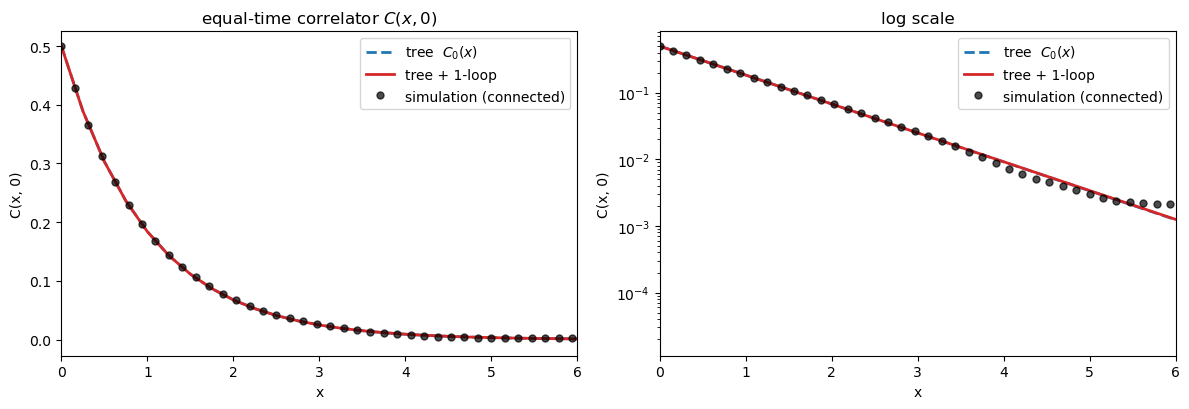

distance |sim − theory| at x=0  (sim connected variance = 0.4998):
   tree                       : |Δ| = 0.0002
   tree + 1-loop              : |Δ| = 0.0001


In [5]:
styles = {0: ('--', 'C0', r'tree  $C_0(x)$'),
          1: ('-',  'C3', 'tree + 1-loop'),
          2: ('-',  'C2', 'tree + 2-loop')}

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for a in ax:
    for ell in orders:
        ls, col, lab = styles[ell]
        a.plot(xs, curves[ell], ls, lw=2, color=col, label=lab)
    a.plot(xc, Cx, 'o', ms=5, color='k', alpha=0.7, label='simulation (connected)')
    a.set_xlabel('x'); a.set_ylabel('C(x, 0)'); a.set_xlim(0, xs.max())
ax[0].set_title('equal-time correlator $C(x,0)$'); ax[0].legend()
ax[1].set_yscale('log'); ax[1].set_title('log scale'); ax[1].legend()
plt.tight_layout(); plt.show()

sim0 = Cx[0]
print('distance |sim − theory| at x=0  (sim connected variance = %.4f):' % sim0)
for ell in orders:
    print('   %-26s : |Δ| = %.4f' % (order_label(ell), abs(sim0 - curves[ell][0])))

## Summary

Burgers is the **composite first-derivative** representative ($\partial_x$ on the $\phi^2$ composite,
imaginary form factor).  The same machinery as Model B, with $\partial_x\to ik$ carried complex and the
saddle-drift handled by the drift-generalized heat kernel.

**Knobs:** `MAX_ELL`, `lam` (Burgers coupling, the loop shift $\propto\lambda^2$), `mu`, `D`, `T`.
The connected variance shift is small and negative (sim $-0.0002\pm0.0002$ vs theory $-0.0001$ at
$\lambda=0.3$ — `docs/kpz_burgers_sim_validation.py`).